In [1]:
import os, random, time, math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Homework text sequence
text = "Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.\n\nAt its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.\n\nOne of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.\n\nTraining a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.\n\nOnce trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.\n\nIn summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."

chars = sorted(list(set(text)))
ix_to_char = {i: ch for i, ch in enumerate(chars)}
char_to_ix = {ch: i for i, ch in enumerate(chars)}

print('Number of characters in text:', len(text))
print('Vocabulary size:', len(chars))
print('Characters:', ''.join(chars))


device: cpu
Number of characters in text: 2391
Vocabulary size: 45
Characters: 
 '(),-.ADILMNOPRSTabcdefghijklmnopqrstuvwxyz


In [2]:
# Preparing the dataset like the class example, but wrapped in a function.
# Difference from the first version: y is now a shifted sequence, not just one final character.
# Example: input "Next" predicts "ext " at each time step.

def make_dataset(max_length):
    encoded = np.array([char_to_ix[ch] for ch in text])
    X = []
    y = []
    for i in range(len(encoded) - max_length):
        sequence = encoded[i:i + max_length]
        label_sequence = encoded[i + 1:i + max_length + 1]
        X.append(sequence)
        y.append(label_sequence)

    X = np.array(X)
    y = np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = make_dataset(10)
print('X train:', X_train.shape, 'y train:', y_train.shape)
print('X val:', X_val.shape, 'y val:', y_val.shape)


X train: torch.Size([1904, 10]) y train: torch.Size([1904, 10])
X val: torch.Size([477, 10]) y val: torch.Size([477, 10])


In [ ]:
# This class is very close to the CharRNN example.
# The main change is that I can switch between RNN, LSTM, and GRU.
# It now returns predictions for every time step, which helps reduce overfitting.

class CharRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, model_type='LSTM', num_layers=1, dropout=0.35):
        super(CharRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.model_type = model_type
        self.embedding = nn.Embedding(input_size, hidden_size)

        if model_type == 'RNN':
            self.rnn = nn.RNN(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        else:
            raise ValueError('model_type must be RNN, LSTM, or GRU')

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.dropout(output)
        output = self.fc(output)
        return output


def get_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return get_params(model) * 4 / (1024 ** 2)


def rough_complexity(model_type, seq_length, hidden_size, num_layers=1):
    # Simple recurrent complexity estimate for comparison only.
    gates = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[model_type]
    return gates * num_layers * seq_length * (hidden_size * hidden_size + hidden_size * hidden_size)


In [4]:
def top_k_accuracy(output, target, k=3):
    # output shape: [N, vocab], target shape: [N]
    _, pred = output.topk(k, dim=1)
    correct = pred.eq(target.view(-1, 1).expand_as(pred))
    return correct.any(dim=1).float().mean().item()


def train_one_model(model_type='LSTM', max_length=10, hidden_size=128, epochs=160, learning_rate=0.0025, dropout=0.35, weight_decay=1e-3, clip_value=1.0, patience=35):
    X_train, X_val, y_train, y_val = make_dataset(max_length)

    model = CharRNNModel(len(chars), hidden_size, len(chars), model_type=model_type, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=12, min_lr=1e-5)

    train_losses = []
    val_losses = []
    val_accs = []
    val_last_accs = []
    val_top3_accs = []
    val_top5_accs = []
    val_top10_accs = []

    best_val_acc = 0
    best_last_acc = 0
    best_val_top3_acc = 0
    best_val_top5_acc = 0
    best_val_top10_acc = 0
    best_val_loss = 999
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve_count = 0

    start = time.time()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output.reshape(-1, len(chars)), y_train.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output.reshape(-1, len(chars)), y_val.reshape(-1))

            flat_output = val_output.reshape(-1, len(chars))
            flat_target = y_val.reshape(-1)
            pred = flat_output.argmax(1)
            val_accuracy = (pred == flat_target).float().mean().item()
            val_top3 = top_k_accuracy(flat_output, flat_target, k=3)
            val_top5 = top_k_accuracy(flat_output, flat_target, k=5)
            val_top10 = top_k_accuracy(flat_output, flat_target, k=10)

            last_output = val_output[:, -1, :]
            last_target = y_val[:, -1]
            last_pred = last_output.argmax(1)
            last_accuracy = (last_pred == last_target).float().mean().item()

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        val_accs.append(val_accuracy)
        val_last_accs.append(last_accuracy)
        val_top3_accs.append(val_top3)
        val_top5_accs.append(val_top5)
        val_top10_accs.append(val_top10)
        scheduler.step(val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_last_acc = last_accuracy
            best_val_top3_acc = val_top3
            best_val_top5_acc = val_top5
            best_val_top10_acc = val_top10
            best_val_loss = val_loss.item()
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if (epoch + 1) % 20 == 0:
            print(model_type, 'seq', max_length, 'epoch', epoch + 1,
                  'loss', round(loss.item(), 4),
                  'val acc', round(val_accuracy, 4),
                  'last acc', round(last_accuracy, 4),
                  'best', round(best_val_acc, 4))

        if no_improve_count >= patience:
            print('Early stopping at epoch', epoch + 1, 'best epoch was', best_epoch)
            break

    total_time = time.time() - start
    model.load_state_dict(best_state)
    epochs_trained = len(train_losses)

    info = {
        'model_type': model_type,
        'seq_length': max_length,
        'hidden_size': hidden_size,
        'epochs_planned': epochs,
        'epochs_trained': epochs_trained,
        'learning_rate': learning_rate,
        'dropout': dropout,
        'weight_decay': weight_decay,
        'clip_value': clip_value,
        'train_loss': train_losses[-1],
        'val_loss': val_losses[-1],
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_last_step_val_acc': best_last_acc,
        'best_val_top3_acc': best_val_top3_acc,
        'best_val_top5_acc': best_val_top5_acc,
        'best_val_top10_acc': best_val_top10_acc,
        'best_epoch': best_epoch,
        'final_val_acc': val_accs[-1],
        'final_last_step_val_acc': val_last_accs[-1],
        'final_val_top3_acc': val_top3_accs[-1],
        'final_val_top5_acc': val_top5_accs[-1],
        'final_val_top10_acc': val_top10_accs[-1],
        'training_time_sec': total_time,
        'params': get_params(model),
        'model_size_MB': model_size_mb(model),
        'rough_complexity': rough_complexity(model_type, max_length, hidden_size),
    }
    return model, info, train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs, val_top10_accs


In [5]:
# Running all required Problem 1 experiments.
# These settings are more regularized so validation accuracy generalizes better.

sequence_lengths = [10, 20, 30]
model_types = ['RNN', 'LSTM', 'GRU']

hidden_size = 128
num_epochs = 350
learning_rate = 0.0025
dropout = 0.35
weight_decay = 1e-3
clip_value = 1.0
patience = 35

all_results = []
history = {}
trained_models = {}

for seq_len in sequence_lengths:
    for mtype in model_types:
        print('\nRUNNING:', mtype, 'sequence length:', seq_len)
        model, info, train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs, val_top10_accs = train_one_model(
            model_type=mtype,
            max_length=seq_len,
            hidden_size=hidden_size,
            epochs=num_epochs,
            learning_rate=learning_rate,
            dropout=dropout,
            weight_decay=weight_decay,
            clip_value=clip_value,
            patience=patience
        )
        all_results.append(info)
        history[(mtype, seq_len)] = (train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs, val_top10_accs)
        trained_models[(mtype, seq_len)] = model

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['seq_length', 'model_type']).reset_index(drop=True)
results_df



RUNNING: RNN sequence length: 10
RNN seq 10 epoch 20 loss 2.3948 val acc 0.3918 last acc 0.4256 best 0.3966
RNN seq 10 epoch 40 loss 2.0735 val acc 0.4763 last acc 0.5052 best 0.4763
RNN seq 10 epoch 60 loss 1.8689 val acc 0.5277 last acc 0.5514 best 0.5277
RNN seq 10 epoch 80 loss 1.7155 val acc 0.5757 last acc 0.6122 best 0.5757
RNN seq 10 epoch 100 loss 1.5861 val acc 0.618 last acc 0.6876 best 0.618
RNN seq 10 epoch 120 loss 1.482 val acc 0.6503 last acc 0.74 best 0.6503
RNN seq 10 epoch 140 loss 1.3844 val acc 0.6761 last acc 0.805 best 0.6761
RNN seq 10 epoch 160 loss 1.3196 val acc 0.6987 last acc 0.8323 best 0.6987
RNN seq 10 epoch 180 loss 1.2767 val acc 0.7176 last acc 0.8679 best 0.7176
RNN seq 10 epoch 200 loss 1.2374 val acc 0.7294 last acc 0.8889 best 0.7294
RNN seq 10 epoch 220 loss 1.2116 val acc 0.7361 last acc 0.9015 best 0.7361
RNN seq 10 epoch 240 loss 1.184 val acc 0.7377 last acc 0.9057 best 0.739
RNN seq 10 epoch 260 loss 1.1649 val acc 0.7379 last acc 0.9119 be

,model_type,seq_length,hidden_size,epochs_planned,epochs_trained,learning_rate,dropout,weight_decay,clip_value,train_loss,...,best_epoch,final_val_acc,final_last_step_val_acc,final_val_top3_acc,final_val_top5_acc,final_val_top10_acc,training_time_sec,params,model_size_MB,rough_complexity
0,GRU,10,128,350,273,0.0025,0.35,0.001,1.0,1.041658,...,238,0.770440,0.932914,0.911950,0.949266,0.985535,77.200388,110637,0.422047,983040
1,LSTM,10,128,350,300,0.0025,0.35,0.001,1.0,1.028403,...,265,0.768344,0.932914,0.910273,0.947379,0.985115,75.185652,143661,0.548023,1310720
2,RNN,10,128,350,283,0.0025,0.35,0.001,1.0,1.154556,...,248,0.741929,0.911950,0.901258,0.945493,0.983229,53.594902,44589,0.170094,327680
3,GRU,20,128,350,283,0.0025,0.35,0.001,1.0,0.781075,...,248,0.882211,0.991579,0.954737,0.975053,0.993158,185.643758,110637,0.422047,1966080
4,LSTM,20,128,350,280,0.0025,0.35,0.001,1.0,0.821458,...,245,0.877368,0.991579,0.952421,0.972316,0.992842,143.058451,143661,0.548023,2621440
5,RNN,20,128,350,339,0.0025,0.35,0.001,1.0,0.887214,...,304,0.864316,0.987368,0.944632,0.970105,0.989579,95.717011,44589,0.170094,655360
6,GRU,30,128,350,243,0.0025,0.35,0.001,1.0,0.720619,...,208,0.920789,0.985201,0.967935,0.982100,0.993939,204.059869,110637,0.422047,2949120
7,LSTM,30,128,350,325,0.0025,0.35,0.001,1.0,0.738119,...,290,0.917125,0.980973,0.967160,0.981325,0.994080,237.996278,143661,0.548023,3932160
8,RNN,30,128,350,339,0.0025,0.35,0.001,1.0,0.787670,...,304,0.903171,0.978858,0.960606,0.979774,0.991684,172.261920,44589,0.170094,983040


In [ ]:
# Save result table
os.makedirs('Results_Problem_1', exist_ok=True)
results_df.to_csv('Results_Problem_1/problem1_results.csv', index=False)
results_df


,model_type,seq_length,hidden_size,epochs_planned,epochs_trained,learning_rate,dropout,weight_decay,clip_value,train_loss,...,best_epoch,final_val_acc,final_last_step_val_acc,final_val_top3_acc,final_val_top5_acc,final_val_top10_acc,training_time_sec,params,model_size_MB,rough_complexity
0,GRU,10,128,350,273,0.0025,0.35,0.001,1.0,1.041658,...,238,0.770440,0.932914,0.911950,0.949266,0.985535,77.200388,110637,0.422047,983040
1,LSTM,10,128,350,300,0.0025,0.35,0.001,1.0,1.028403,...,265,0.768344,0.932914,0.910273,0.947379,0.985115,75.185652,143661,0.548023,1310720
2,RNN,10,128,350,283,0.0025,0.35,0.001,1.0,1.154556,...,248,0.741929,0.911950,0.901258,0.945493,0.983229,53.594902,44589,0.170094,327680
3,GRU,20,128,350,283,0.0025,0.35,0.001,1.0,0.781075,...,248,0.882211,0.991579,0.954737,0.975053,0.993158,185.643758,110637,0.422047,1966080
4,LSTM,20,128,350,280,0.0025,0.35,0.001,1.0,0.821458,...,245,0.877368,0.991579,0.952421,0.972316,0.992842,143.058451,143661,0.548023,2621440
5,RNN,20,128,350,339,0.0025,0.35,0.001,1.0,0.887214,...,304,0.864316,0.987368,0.944632,0.970105,0.989579,95.717011,44589,0.170094,655360
6,GRU,30,128,350,243,0.0025,0.35,0.001,1.0,0.720619,...,208,0.920789,0.985201,0.967935,0.982100,0.993939,204.059869,110637,0.422047,2949120
7,LSTM,30,128,350,325,0.0025,0.35,0.001,1.0,0.738119,...,290,0.917125,0.980973,0.967160,0.981325,0.994080,237.996278,143661,0.548023,3932160
8,RNN,30,128,350,339,0.0025,0.35,0.001,1.0,0.787670,...,304,0.903171,0.978858,0.960606,0.979774,0.991684,172.261920,44589,0.170094,983040


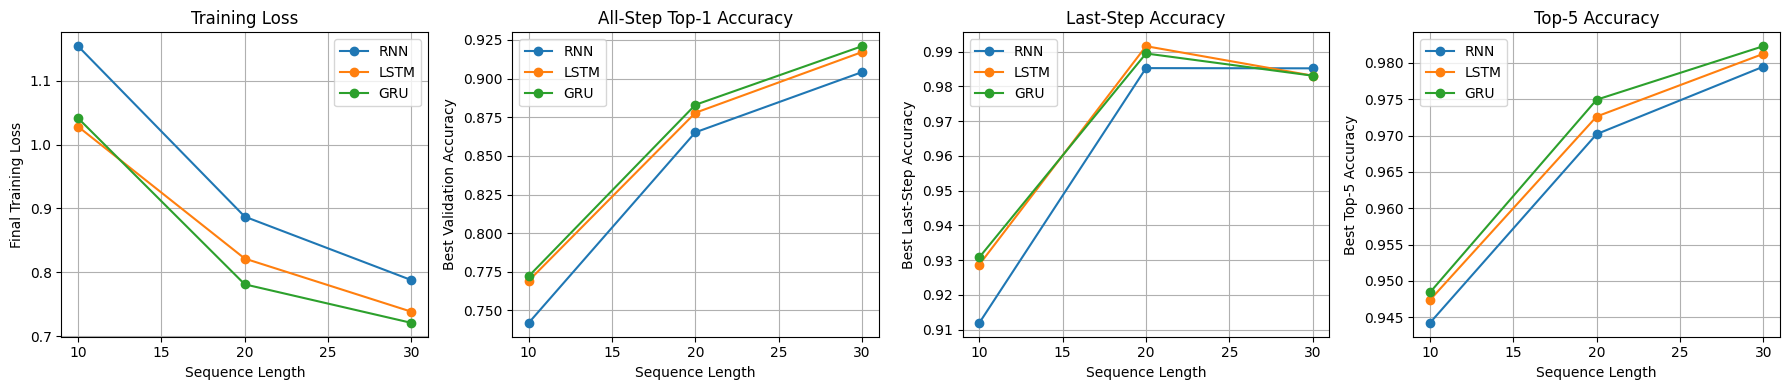

In [ ]:
# Plot final training loss and validation accuracy comparisons
plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
for mtype in model_types:
    temp = results_df[results_df['model_type'] == mtype]
    plt.plot(temp['seq_length'], temp['train_loss'], marker='o', label=mtype)
plt.xlabel('Sequence Length')
plt.ylabel('Final Training Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,4,2)
for mtype in model_types:
    temp = results_df[results_df['model_type'] == mtype]
    plt.plot(temp['seq_length'], temp['best_val_acc'], marker='o', label=mtype)
plt.xlabel('Sequence Length')
plt.ylabel('Best Validation Accuracy')
plt.title('All-Step Top-1 Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,4,3)
for mtype in model_types:
    temp = results_df[results_df['model_type'] == mtype]
    plt.plot(temp['seq_length'], temp['best_last_step_val_acc'], marker='o', label=mtype)
plt.xlabel('Sequence Length')
plt.ylabel('Best Last-Step Accuracy')
plt.title('Last-Step Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,4,4)
for mtype in model_types:
    temp = results_df[results_df['model_type'] == mtype]
    plt.plot(temp['seq_length'], temp['best_val_top5_acc'], marker='o', label=mtype)
plt.xlabel('Sequence Length')
plt.ylabel('Best Top-5 Accuracy')
plt.title('Top-5 Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Results_Problem_1/problem1_summary_generalized.png', dpi=200, bbox_inches='tight')
plt.show()


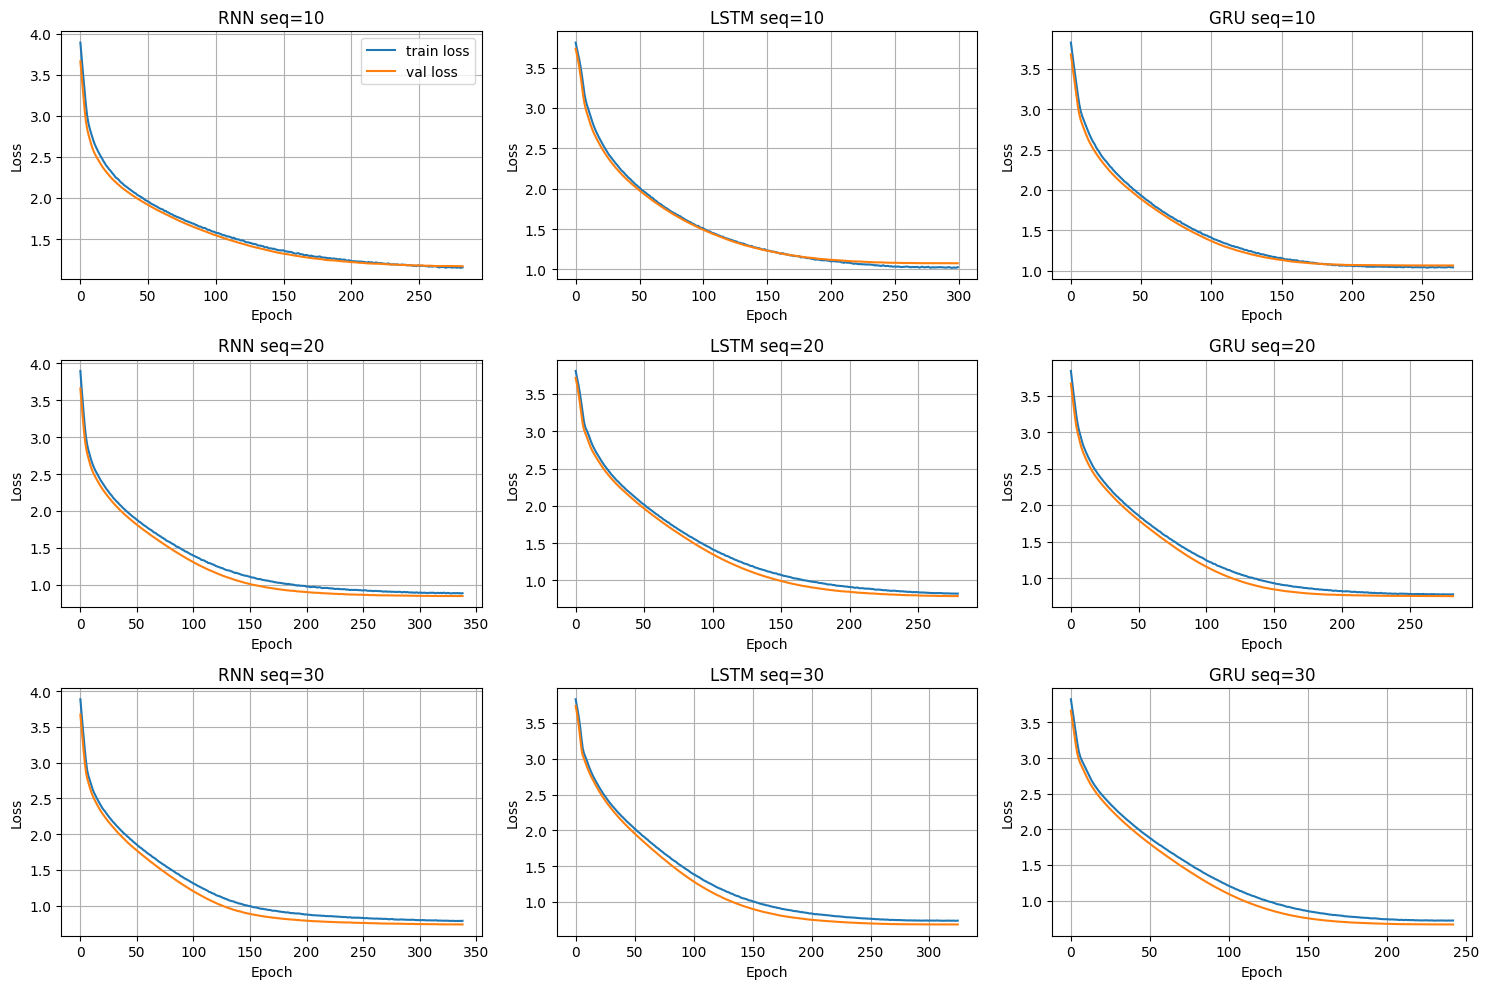

In [ ]:
# Plot learning curves for every model and sequence length
plt.figure(figsize=(15,10))
plot_num = 1
for seq_len in sequence_lengths:
    for mtype in model_types:
        train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs, val_top10_accs = history[(mtype, seq_len)]
        plt.subplot(3,3,plot_num)
        plt.plot(train_losses, label='train loss')
        plt.plot(val_losses, label='val loss')
        plt.title(mtype + ' seq=' + str(seq_len))
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        if plot_num == 1:
            plt.legend()
        plot_num += 1
plt.tight_layout()
plt.savefig('Results_Problem_1/problem1_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()


In [9]:
def predict_next_char(model, initial_str, max_length):
    model.eval()
    with torch.no_grad():
        initial_str = initial_str[-max_length:]
        x = torch.tensor([char_to_ix.get(c, char_to_ix[' ']) for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
        prediction = model(x)
        last_prediction = prediction[:, -1, :]
        predicted_index = torch.argmax(last_prediction, dim=1).item()
        return ix_to_char[predicted_index]


def generate_text(model, start_text, max_length, predict_len=200):
    generated = start_text
    for i in range(predict_len):
        next_char = predict_next_char(model, generated, max_length)
        generated += next_char
    return generated

best_row = results_df.sort_values('best_val_acc', ascending=False).iloc[0]
best_key = (best_row['model_type'], int(best_row['seq_length']))
best_model = trained_models[best_key]

print('Best model by all-step validation accuracy:', best_key)
print('All-step top-1:', best_row['best_val_acc'])
print('Last-step top-1:', best_row['best_last_step_val_acc'])
print('Top-5:', best_row['best_val_top5_acc'])
print(generate_text(best_model, 'Next character prediction', best_key[1], 300))


Best model by all-step validation accuracy: ('GRU', 30)
All-step top-1: 0.9210007190704346
Last-step top-1: 0.9830867052078247
Top-5: 0.982311487197876
Next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of t
